In [1]:
# STAGE 0 — Notebook Setup (Paths, Imports, Config) — PDFPLUMBER ONLY

from pathlib import Path
import re
import json
import math
import time
import logging
from typing import Dict, List, Any, Optional, Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PDF_PATH = Path("../data/raw/EMV_v4.4_Book_2_Security_and_Key_Management.pdf")
OUT_DIR = Path("../data/Book2/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# TOC (1-indexed pages as printed in PDF viewer)
TOC_START_PAGE = 4
TOC_END_PAGE = 7

# Logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger("emv_phase2_pdfplumber")

print(f"PDF: {PDF_PATH.resolve()}")
print(f"Output directory: {OUT_DIR.resolve()}")

PDF: /app/data/raw/EMV_v4.4_Book_2_Security_and_Key_Management.pdf
Output directory: /app/data/Book2


In [2]:
# STAGE 0.1 — Dependency Check

try:
    import pdfplumber
except Exception as e:
    raise RuntimeError(f"pdfplumber not available: {e}")

print("pdfplumber available.")

pdfplumber available.


In [3]:
# STAGE 1 — Clean Raw Text Extraction (pdfplumber)
# - Extract per page: page_num, raw_text, cleaned_text_minimal
# - Header removal: known header patterns (with/without section name)
# - Footer removal: known footer block patterns
# - Preserve all other content
# - Produce per-page quality report + warnings

PAGE_LINE_RE = re.compile(r"^\s*October\s+2022\s+Page\s+\d+\s*$", re.IGNORECASE)

HEADER_LINE_1_RE = re.compile(r"^\s*EMV\s*4\.4\s*Book\s*2\b.*$", re.IGNORECASE)
HEADER_LINE_2_RE = re.compile(r"^\s*Security\s+and\s+Key\s+Management\b.*$", re.IGNORECASE)

COPYRIGHT_START_RE = re.compile(r"^\s*©\s*1994-2022\s+EMVCo,?\s+LLC.*$", re.IGNORECASE)
COPYRIGHT_ANY_RE = re.compile(r"^\s*(©|EMVCo|States|this\s+document|Reproduction|found\s+at\s+www\.emvco\.com|EMV®).*$", re.IGNORECASE)

def split_lines(text: str) -> List[str]:
    if not text:
        return []
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    return text.split("\n")

def normalize_ws(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())

def is_header_line(line: str) -> bool:
    ln = normalize_ws(line)
    if not ln:
        return False
    return bool(
        HEADER_LINE_1_RE.match(ln)
        or HEADER_LINE_2_RE.match(ln)
    )

def is_footer_line(line: str) -> bool:
    ln = normalize_ws(line)
    if not ln:
        return False
    if PAGE_LINE_RE.match(ln):
        return True
    if COPYRIGHT_START_RE.match(ln):
        return True
    if COPYRIGHT_ANY_RE.match(ln):
        return True
    return False

def minimal_clean_emv(raw_text: str) -> Tuple[str, Dict[str, Any]]:
    """
    Remove:
      - header lines matching known header patterns
      - footer lines matching known footer patterns (incl. 'October 2022 Page X' + copyright block)
    Preserve everything else.
    """
    lines = split_lines(raw_text)
    removed = 0
    removed_examples = []
    kept = []

    for ln in lines:
        if is_header_line(ln) or is_footer_line(ln):
            removed += 1
            if len(removed_examples) < 8:
                removed_examples.append(normalize_ws(ln))
            continue
        kept.append(ln)

    cleaned = "\n".join(kept)
    meta = {
        "removed_lines": removed,
        "removed_examples": removed_examples,
        "raw_chars": len(raw_text or ""),
        "cleaned_chars": len(cleaned or ""),
        "raw_words": len(re.findall(r"\w+", raw_text or "")),
        "cleaned_words": len(re.findall(r"\w+", cleaned or "")),
        "raw_lines": len(lines),
        "cleaned_lines": len(split_lines(cleaned)),
    }
    return cleaned, meta

def quality_signals(text: str) -> Dict[str, Any]:
    lines = [ln for ln in split_lines(text) if ln.strip()]
    return {
        "chars": len(text or ""),
        "words": len(re.findall(r"\w+", text or "")),
        "lines_nonempty": len(lines),
        "avg_line_len": float(np.mean([len(ln) for ln in lines])) if lines else 0.0,
        "space_noise_lines": sum(1 for ln in lines if re.search(r"[ \t]{3,}", ln)),
    }

def extract_pages_pdfplumber(pdf_path: Path) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    t0 = time.perf_counter()
    rows = []
    warnings = []
    with pdfplumber.open(str(pdf_path)) as pdf:
        num_pages = len(pdf.pages)
        for i, page in enumerate(pdf.pages, start=1):
            raw = page.extract_text() or ""
            cleaned, meta = minimal_clean_emv(raw)

            q_raw = quality_signals(raw)
            q_clean = quality_signals(cleaned)

            if q_raw["words"] > 0 and q_clean["words"] < max(50, int(0.1 * q_raw["words"])):
                warnings.append({
                    "page": i,
                    "type": "low_content_after_clean",
                    "message": f"Cleaned words unusually low ({q_clean['words']}) vs raw ({q_raw['words']})."
                })

            rows.append({
                "extractor": "pdfplumber",
                "page_num": i,
                "raw_text": raw,
                "cleaned_text_minimal": cleaned,
                **meta,
                "raw_space_noise_lines": q_raw["space_noise_lines"],
                "clean_space_noise_lines": q_clean["space_noise_lines"],
            })

    dt = time.perf_counter() - t0
    report = {
        "extractor": "pdfplumber",
        "seconds": dt,
        "num_pages": num_pages,
        "warnings": warnings,
    }
    return pd.DataFrame(rows), report

df_pages, quality_report = extract_pages_pdfplumber(PDF_PATH)
df_quality = pd.DataFrame([quality_report])
df_pages.to_json(OUT_DIR / 'df_pages.json', orient='records', indent=4, force_ascii=False)
display(df_quality)
display(df_pages.head(3))

,extractor,seconds,num_pages,warnings
0,pdfplumber,10.484963,192,"[{'page': 1, 'type': 'low_content_after_clean'..."


,extractor,page_num,raw_text,cleaned_text_minimal,removed_lines,removed_examples,raw_chars,cleaned_chars,raw_words,cleaned_words,raw_lines,cleaned_lines,raw_space_noise_lines,clean_space_noise_lines
0,pdfplumber,1,®\nEMV\nIntegrated Circuit Card\nSpecification...,®\nEMV\nIntegrated Circuit Card\nSpecification...,5,"[Security and Key Management, © 1994-2022 EMVC...",443,96,70,15,12,7,0,0
1,pdfplumber,2,EMV 4.4 Book 2\nSecurity and Key Management\nT...,The EMV® Specifications are provided “AS IS” w...,9,"[EMV 4.4 Book 2, Security and Key Management, ...",1912,1355,282,194,25,16,0,0
2,pdfplumber,3,EMV 4.4 Book 2\nSecurity and Key Management\nR...,Revision Log – Version 4.4\nThe following chan...,7,"[EMV 4.4 Book 2, Security and Key Management, ...",1587,1205,227,163,26,19,0,0


In [4]:
# STAGE 2 — Heading Detection Engine (FROM TOC)
# Parse TOC pages (4..6) to detect full hierarchy.
#
# TOC format example:
# Part I – General
# 1 Scope 10
# 1.1 Changes in Version 4.4 10
# ...
#
# Rightmost number is the page containing the title.
# We will build hierarchy from TOC and later locate exact section starts in body by matching TOC titles.

PART_TOC_RE = re.compile(r"^\s*Part\s+([IVX]+)\s*[–-]\s*(.+?)\s*$", re.IGNORECASE)
NUM_TOC_RE  = re.compile(r"^\s*(\d+(?:\.\d+)*)\s+(.+?)\s+(\d+)\s*$")

# Appendices are ONLY in these forms
APPENDIX_RE  = re.compile(r"^\s*(Appendix|Annex)\s+([A-Z])\b\s*(.*?)\s+(\d+)\s*$", re.IGNORECASE)
SUBAPP_RE    = re.compile(r"^\s*([A-Z])(\d+)\s+(.+?)\s+(\d+)\s*$")
SUBSUBAPP_RE = re.compile(r"^\s*([A-Z])(\d+)\.(\d+)\s+(.+?)\s+(\d+)\s*$")

def toc_level(kind: str, section_id: str) -> int:
    # Depth rule:
    # Part/Appendix roots = Level 1
    # Numeric: 1 => L2, 1.1 => L3, 1.1.1 => L4...
    if kind == "part":
        return 1
    if kind in {"appendix", "annex"}:
        return 2
    if kind == "numeric":
        return 2 + section_id.count(".")
    if kind == "subappendix":
        return 3 + section_id.count(".")
    return 2

def extract_toc_text(df_pages: pd.DataFrame, start_page: int, end_page: int) -> str:
    parts = []
    for p in range(start_page, end_page + 1):
        txt = df_pages.loc[df_pages["page_num"] == p, "cleaned_text_minimal"].values
        parts.append(txt[0] if len(txt) else "")
    return "\n".join(parts)

toc_text = extract_toc_text(df_pages, TOC_START_PAGE, TOC_END_PAGE)
toc_lines = [ln for ln in split_lines(toc_text) if normalize_ws(ln)]

# Find "Contents" then parse after it (robust)
start_idx = 0
for i, ln in enumerate(toc_lines):
    if normalize_ws(ln).lower() == "contents":
        start_idx = i + 1
        break

toc_entries = []
warnings_toc = []
current_part = None

for ln in toc_lines[start_idx:]:
    s = normalize_ws(ln)

    m = PART_TOC_RE.match(s)
    if m:
        part_roman = m.group(1).upper()
        part_title = m.group(2).strip()
        sec_id = f"Part {part_roman}"
        toc_entries.append({
            "kind": "part",
            "section_id": sec_id,
            "title": part_title,
            "toc_page_ref": None,   # Part lines typically don't include right-side page
            "source": "toc",
            "raw_line": s
        })
        current_part = sec_id
        continue

    m = APPENDIX_RE.match(s)
    if m:
        kind = m.group(1).lower()
        letter = m.group(2).upper()
        title = (m.group(3) or "").strip()
        page_ref = int(m.group(4))
        sec_id = f"{m.group(1).title()} {letter}"
        toc_entries.append({
            "kind": kind,
            "section_id": sec_id,
            "title": title,
            "toc_page_ref": page_ref,
            "source": "toc",
            "raw_line": s
        })
        continue

    m = SUBSUBAPP_RE.match(s)
    if m:
        letter = m.group(1).upper()
        a = m.group(2)
        b = m.group(3)
        title = m.group(4).strip()
        page_ref = int(m.group(5))
        sec_id = f"{letter}{a}.{b}"
        toc_entries.append({
            "kind": "subappendix",
            "section_id": sec_id,
            "title": title,
            "toc_page_ref": page_ref,
            "source": "toc",
            "raw_line": s
        })
        continue

    m = SUBAPP_RE.match(s)
    if m:
        letter = m.group(1).upper()
        a = m.group(2)
        title = m.group(3).strip()
        page_ref = int(m.group(4))
        sec_id = f"{letter}{a}"
        toc_entries.append({
            "kind": "subappendix",
            "section_id": sec_id,
            "title": title,
            "toc_page_ref": page_ref,
            "source": "toc",
            "raw_line": s
        })
        continue

    m = NUM_TOC_RE.match(s)
    if m:
        sec_id = m.group(1)
        title = m.group(2).strip()
        page_ref = int(m.group(3))
        toc_entries.append({
            "kind": "numeric",
            "section_id": sec_id,
            "title": title,
            "toc_page_ref": page_ref,
            "source": "toc",
            "raw_line": s
        })
        continue

    # ignore obvious non-entry lines; warn if looks like entry but not parsed
    if re.search(r"\d+\s*$", s) and len(s) > 10:
        warnings_toc.append({"type": "unparsed_toc_line", "line": s})

df_toc = pd.DataFrame(toc_entries)
if not df_toc.empty:
    df_toc["level"] = [toc_level(k, sid) for k, sid in zip(df_toc["kind"], df_toc["section_id"])]
else:
    df_toc["level"] = []

display(df_toc.head(50))
print(f"TOC entries parsed: {len(df_toc)}")
if warnings_toc:
    display(pd.DataFrame(warnings_toc).head(50))

,kind,section_id,title,toc_page_ref,source,raw_line,level
0,part,Part I,General,NaN,toc,Part I – General,1
1,numeric,1,Scope,12.0,toc,1 Scope 12,2
2,numeric,1.1,Changes in Version 4.4,12.0,toc,1.1 Changes in Version 4.4 12,3
3,numeric,1.2,Structure,12.0,toc,1.2 Structure 12,3
4,numeric,1.3,Underlying Standards,13.0,toc,1.3 Underlying Standards 13,3
5,numeric,1.4,Audience,13.0,toc,1.4 Audience 13,3
6,numeric,2,Normative References,14.0,toc,2 Normative References 14,2
7,numeric,3,Definitions,17.0,toc,3 Definitions 17,2
8,numeric,4,"Abbreviations, Notations, Conventions, and Ter...",25.0,toc,"4 Abbreviations, Notations, Conventions, and T...",2
9,numeric,4.1,Abbreviations,25.0,toc,4.1 Abbreviations 25,3


TOC entries parsed: 131


,type,line
0,unparsed_toc_line,Common Core Definitions 183
1,unparsed_toc_line,Changed Sections 183


In [5]:
# STAGE 3 — Determine Hierarchy Depth (from TOC)

if df_toc.empty:
    max_depth = 0
    avg_depth = 0.0
    depth_dist = {}
else:
    max_depth = int(df_toc["level"].max())
    avg_depth = float(df_toc["level"].mean())
    depth_dist = df_toc["level"].value_counts().sort_index().to_dict()

depth_summary = {
    "max_depth": max_depth,
    "avg_depth": avg_depth,
    "depth_distribution": {str(k): int(v) for k, v in depth_dist.items()},
    "num_headings": int(len(df_toc))
}
print(depth_summary)

{'max_depth': 4, 'avg_depth': 3.1526717557251906, 'depth_distribution': {'1': 4, '2': 20, '3': 59, '4': 48}, 'num_headings': 131}


In [6]:
# STAGE 4 — Build Hierarchical Tree (from TOC)
# Parent = closest previous heading with strictly lower level

def assign_parents_from_levels(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df.assign(node_id=[], parent_node_id=[])

    out = df.copy().reset_index(drop=True)
    out["node_id"] = [f"T{i+1}:{sid}" for i, sid in enumerate(out["section_id"].tolist())]
    out["parent_node_id"] = None

    stack: List[Tuple[int, str]] = []  # (level, node_id)
    warnings = []

    for i, r in out.iterrows():
        lvl = int(r["level"])
        nid = r["node_id"]

        while stack and stack[-1][0] >= lvl:
            stack.pop()

        if stack:
            out.at[i, "parent_node_id"] = stack[-1][1]
        else:
            out.at[i, "parent_node_id"] = None

        # orphan check: numeric level >2 with no parent
        if lvl > 2 and out.at[i, "parent_node_id"] is None:
            warnings.append({
                "type": "orphan_toc_heading",
                "message": f"Orphan TOC heading without parent: L{lvl} {r['section_id']} {r['title']}",
                "raw_line": r.get("raw_line", "")
            })

        stack.append((lvl, nid))

    return out, warnings

df_toc2, warnings_hierarchy = assign_parents_from_levels(df_toc)

display(df_toc2.head(40))
if warnings_hierarchy:
    display(pd.DataFrame(warnings_hierarchy).head(50))

def build_tree_from_flat(df_flat: pd.DataFrame) -> Dict[str, Any]:
    root = {"node_id": "ROOT", "section_id": "ROOT", "title": "Document Root", "level": 0, "children": []}
    if df_flat.empty:
        return root

    nodes = {}
    for _, r in df_flat.iterrows():
        nid = r["node_id"]
        nodes[nid] = {
            "node_id": nid,
            "section_id": r["section_id"],
            "title": r["title"],
            "level": int(r["level"]),
            "kind": r["kind"],
            "toc_page_ref": None if pd.isna(r["toc_page_ref"]) else int(r["toc_page_ref"]),
            "children": []
        }

    for _, r in df_flat.iterrows():
        nid = r["node_id"]
        pid = r["parent_node_id"]
        if pid is None or pid not in nodes:
            root["children"].append(nodes[nid])
        else:
            nodes[pid]["children"].append(nodes[nid])

    return root

hierarchy_tree = build_tree_from_flat(df_toc2)

with open(OUT_DIR / "hierarchy.json", "w", encoding="utf-8") as f:
    json.dump(hierarchy_tree, f, ensure_ascii=False, indent=2)

# Save headings.csv (TOC-based)
df_headings_out = df_toc2[["node_id","parent_node_id","section_id","title","level","kind","toc_page_ref"]].copy()
df_headings_out.to_csv(OUT_DIR / "headings.csv", index=False)

print("Saved:")
print(" - hierarchy.json")
print(" - headings.csv")

,kind,section_id,title,toc_page_ref,source,raw_line,level,node_id,parent_node_id
0,part,Part I,General,NaN,toc,Part I – General,1,T1:Part I,None
1,numeric,1,Scope,12.0,toc,1 Scope 12,2,T2:1,T1:Part I
2,numeric,1.1,Changes in Version 4.4,12.0,toc,1.1 Changes in Version 4.4 12,3,T3:1.1,T2:1
3,numeric,1.2,Structure,12.0,toc,1.2 Structure 12,3,T4:1.2,T2:1
4,numeric,1.3,Underlying Standards,13.0,toc,1.3 Underlying Standards 13,3,T5:1.3,T2:1
5,numeric,1.4,Audience,13.0,toc,1.4 Audience 13,3,T6:1.4,T2:1
6,numeric,2,Normative References,14.0,toc,2 Normative References 14,2,T7:2,T1:Part I
7,numeric,3,Definitions,17.0,toc,3 Definitions 17,2,T8:3,T1:Part I
8,numeric,4,"Abbreviations, Notations, Conventions, and Ter...",25.0,toc,"4 Abbreviations, Notations, Conventions, and T...",2,T9:4,T1:Part I
9,numeric,4.1,Abbreviations,25.0,toc,4.1 Abbreviations 25,3,T10:4.1,T9:4


Saved:
 - hierarchy.json
 - headings.csv


In [7]:
# STAGE 5 — FIX: Prevent “Part III/IV” (and any heading) from matching earlier mentions (e.g., page 12),
# and ensure section boundaries are computed in DOCUMENT ORDER (by matched position), not TOC order.
#
# What this cell does:
# 1) Builds df_lines + df_windows (joined 1–3 lines)
# 2) Matches each TOC heading with a HARD minimum page constraint:
#       - For Parts: use your known Part start pages (III=132, IV=182, etc.)
#       - Otherwise: use toc_page_ref (or MIN_BODY_PAGE if missing)
#    => This blocks false matches like the “Book 2 consists of the following parts...” paragraph on page 12.
# 3) Builds df_positions
# 4) Builds df_sections IN DOCUMENT ORDER (sorted by global_line_idx), which prevents end_page < start_page.
# 5) Saves stage5_warnings.json + sections.csv

MIN_BODY_PAGE = TOC_END_PAGE + 1

PART_START_PAGES = {
    "Part I": 10,
    "Part II": 12,
    "Part III": 132,
    "Part IV": 182,
}

# -----------------------------
# Build line-level index
# -----------------------------
def build_line_index(df_pages: pd.DataFrame, start_page: int = 1) -> pd.DataFrame:
    rows = []
    gl = 0
    for _, r in df_pages.sort_values("page_num").iterrows():
        page = int(r["page_num"])
        if page < start_page:
            continue
        lines = split_lines(r["cleaned_text_minimal"])
        for li, ln in enumerate(lines):
            gl += 1
            rows.append({
                "page_num": page,
                "line_idx_in_page": li,
                "global_line_idx": gl,
                "line_text": ln,
                "line_norm": normalize_ws(ln).lower(),
            })
    return pd.DataFrame(rows)

df_lines = build_line_index(df_pages, start_page=1)

# -----------------------------
# Normalization helpers
# -----------------------------
def normalize_for_match(s: str) -> str:
    s = normalize_ws(s).lower()
    s = s.replace("–", "-").replace("—", "-")
    s = re.sub(r"[“”\"']", "", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def make_heading_candidates(section_id: str, title: str, kind: str) -> List[str]:
    sid = normalize_for_match(section_id)
    ttl = normalize_for_match(title)
    cands = []

    if kind.lower() == "part":
        # Allow matching "part iii" alone and also "part iii annexes"
        if ttl:
            cands.append(f"{sid} {ttl}".strip())
            cands.append(f"{sid} - {ttl}".strip())
        cands.append(sid)
    else:
        if ttl:
            cands.append(f"{sid} {ttl}".strip())
        if sid:
            cands.append(sid)
        if ttl and len(ttl) >= 4:
            cands.append(ttl)

    out, seen = [], set()
    for c in cands:
        c2 = normalize_for_match(c)
        if c2 and c2 not in seen:
            seen.add(c2)
            out.append(c2)
    return out

# -----------------------------
# Build joined windows (1–3 lines)
# -----------------------------
def build_joined_windows(df_lines: pd.DataFrame, max_join: int = 3) -> pd.DataFrame:
    out = []
    for page, g in df_lines.groupby("page_num"):
        g2 = g.sort_values("line_idx_in_page").reset_index(drop=True)
        lines = g2["line_text"].tolist()
        gls = g2["global_line_idx"].tolist()

        for i in range(len(lines)):
            for L in range(1, max_join + 1):
                if i + L - 1 >= len(lines):
                    continue
                chunk = " ".join([normalize_ws(x) for x in lines[i:i+L] if normalize_ws(x)])
                if not chunk:
                    continue
                out.append({
                    "page_num": int(page),
                    "join_len": L,
                    "start_line_idx_in_page": int(g2.loc[i, "line_idx_in_page"]),
                    "end_line_idx_in_page": int(g2.loc[i+L-1, "line_idx_in_page"]),
                    "start_global_line_idx": int(gls[i]),
                    "text_joined": chunk,
                    "norm_joined": normalize_for_match(chunk),
                })
    return pd.DataFrame(out)

df_windows = build_joined_windows(df_lines, max_join=3)

# -----------------------------
# Scoring + heading finder with HARD min_page constraint
# -----------------------------
def score_match(norm_text: str, cand: str) -> Tuple[float, str]:
    if norm_text == cand:
        return 0.95, "exact"
    if norm_text.startswith(cand):
        return 0.85, "startswith"
    if cand in norm_text and len(cand) >= 8:
        return 0.70, "contains"
    return -1.0, ""

def expected_min_page(toc_row: pd.Series) -> int:
    kind = str(toc_row["kind"]).lower()
    sid = str(toc_row["section_id"]).strip()
    if kind == "part" and sid in PART_START_PAGES:
        return PART_START_PAGES[sid]
    if pd.notna(toc_row.get("toc_page_ref", np.nan)):
        return max(MIN_BODY_PAGE, int(toc_row["toc_page_ref"]))
    return MIN_BODY_PAGE

def find_heading_position_windows_strict(
    df_windows: pd.DataFrame,
    toc_row: pd.Series,
    max_scan_pages: int = 200
) -> Tuple[Optional[Dict[str, Any]], List[Dict[str, Any]]]:
    sid = str(toc_row["section_id"])
    title = str(toc_row["title"] or "")
    kind = str(toc_row["kind"])
    level = int(toc_row["level"])

    min_page = expected_min_page(toc_row)
    end_page = min(int(df_windows["page_num"].max()), min_page + max_scan_pages)

    window = df_windows[(df_windows["page_num"] >= min_page) & (df_windows["page_num"] <= end_page)].copy()
    if window.empty:
        return None, [{
            "type": "empty_search_window",
            "section_id": sid,
            "min_page": min_page,
            "end_page": end_page
        }]

    candidates = make_heading_candidates(sid, title, kind)

    best = None
    best_score = -1.0

    for cand in candidates:
        cand_first = cand.split(" ")[0] if cand else ""
        pre = window
        if cand_first:
            tmp = window[window["norm_joined"].str.contains(re.escape(cand_first), na=False)]
            if not tmp.empty:
                pre = tmp

        for _, w in pre.iterrows():
            sc, mtype = score_match(w["norm_joined"], cand)
            if sc > best_score:
                best_score = sc
                best = {
                    "page": int(w["page_num"]),
                    "global_line_idx": int(w["start_global_line_idx"]),
                    "line_idx_in_page": int(w["start_line_idx_in_page"]),
                    "matched_text": w["text_joined"],
                    "match_type": mtype,
                    "match_confidence": float(sc),
                    "join_len": int(w["join_len"]),
                    "search_start_page": int(min_page),
                    "search_end_page": int(end_page),
                }
            if sc >= 0.95:
                return best, []

    warnings = []
    if best is None:
        warnings.append({
            "type": "heading_not_found",
            "section_id": sid,
            "title": title,
            "kind": kind,
            "level": level,
            "min_page": min_page,
            "end_page": end_page
        })
        return None, warnings

    if best_score < 0.70:
        warnings.append({
            "type": "low_confidence_match",
            "section_id": sid,
            "title": title,
            "kind": kind,
            "level": level,
            "min_page": min_page,
            "match_confidence": float(best_score),
            "match_type": best.get("match_type"),
            "page": best.get("page"),
            "matched_text": (best.get("matched_text") or "")[:200],
        })

    # IMPORTANT: if somehow a match is earlier than min_page (shouldn't happen), discard it
    if best["page"] < min_page:
        warnings.append({
            "type": "discarded_match_before_min_page",
            "section_id": sid,
            "title": title,
            "kind": kind,
            "level": level,
            "min_page": min_page,
            "matched_page": best["page"],
            "matched_text": (best.get("matched_text") or "")[:200],
        })
        return None, warnings

    return best, warnings

# -----------------------------
# Locate heading positions (STRICT)
# -----------------------------
positions = []
stage5_warnings = []

for _, r in df_toc2.iterrows():
    pos, warns = find_heading_position_windows_strict(df_windows, r, max_scan_pages=220)
    stage5_warnings.extend(warns)

    positions.append({
        "node_id": r["node_id"],
        "section_id": r["section_id"],
        "title": r["title"],
        "level": int(r["level"]),
        "kind": r["kind"],
        "toc_page_ref": None if pd.isna(r["toc_page_ref"]) else int(r["toc_page_ref"]),
        "parent_node_id": r["parent_node_id"],
        "expected_min_page": expected_min_page(r),
        **(pos or {
            "page": None,
            "global_line_idx": None,
            "line_idx_in_page": None,
            "matched_text": None,
            "match_type": None,
            "match_confidence": 0.0,
            "join_len": None,
            "search_start_page": expected_min_page(r),
            "search_end_page": None
        })
    })

df_positions = pd.DataFrame(positions)

# Quick check: show Parts
display(df_positions[df_positions["kind"].str.lower()=="part"][["section_id","title","expected_min_page","page","match_type","match_confidence","matched_text"]])

# Save warnings
if stage5_warnings:
    with open(OUT_DIR / "stage5_warnings.json", "w", encoding="utf-8") as f:
        json.dump(stage5_warnings, f, ensure_ascii=False, indent=2)
    print("Saved stage5_warnings.json")

# -----------------------------
# STAGE 5.1 — Build sections IN DOCUMENT ORDER (by matched global_line_idx)
# This fixes end_page < start_page caused by TOC-order boundaries when some matches land earlier.
# -----------------------------
df_pos_valid = df_positions[pd.notna(df_positions["global_line_idx"])].copy()
df_pos_valid["global_line_idx"] = df_pos_valid["global_line_idx"].astype(int)
df_pos_valid = df_pos_valid.sort_values(["global_line_idx"]).reset_index(drop=True)

# Warn if any heading is still missing
missing_cnt = int((df_positions["global_line_idx"].isna()).sum())
if missing_cnt > 0:
    stage5_warnings.append({"type": "missing_heading_positions", "count": missing_cnt})
    print(f"WARNING: {missing_cnt} TOC headings have no matched position; they will be skipped in section slicing.")

max_global = int(df_lines["global_line_idx"].max()) if not df_lines.empty else 0

sections = []
for i in range(len(df_pos_valid)):
    cur = df_pos_valid.iloc[i]
    cur_lvl = int(cur["level"])
    cur_start = int(cur["global_line_idx"])

    # next heading of same or higher level (level <= cur_lvl) in DOCUMENT ORDER
    next_start = None
    for j in range(i + 1, len(df_pos_valid)):
        nxt = df_pos_valid.iloc[j]
        if int(nxt["level"]) <= cur_lvl:
            next_start = int(nxt["global_line_idx"])
            break

    content_start = cur_start + 1
    content_end = (next_start - 1) if next_start is not None else max_global
    if content_end < content_start:
        # no content window; keep empty
        content_start = content_end

    mask = (df_lines["global_line_idx"] >= content_start) & (df_lines["global_line_idx"] <= content_end)
    content_lines = df_lines.loc[mask, "line_text"].tolist()
    text = "\n".join(content_lines).strip("\n")

    start_page = int(cur["page"]) if pd.notna(cur["page"]) else int(df_lines.loc[df_lines["global_line_idx"] == cur_start, "page_num"].min())
    end_page = int(df_lines.loc[df_lines["global_line_idx"] <= content_end, "page_num"].max()) if not df_lines.empty else start_page

    # Final safety: ensure end_page >= start_page
    if end_page < start_page:
        stage5_warnings.append({
            "type": "end_page_before_start_page_fixed",
            "section_id": cur["section_id"],
            "start_page": start_page,
            "end_page_before": end_page
        })
        end_page = start_page

    sections.append({
        "node_id": cur["node_id"],
        "section_id": cur["section_id"],
        "title": cur["title"],
        "level": int(cur["level"]),
        "parent_node_id": cur["parent_node_id"],
        "start_page": start_page,
        "end_page": end_page,
        "start_global_line_idx": cur_start,
        "end_global_line_idx": int(content_end),
        "match_type": cur.get("match_type", None),
        "match_confidence": float(cur.get("match_confidence", 0.0)),
        "expected_min_page": int(cur.get("expected_min_page", MIN_BODY_PAGE)),
        "text": text
    })

df_sections = pd.DataFrame(sections)

# Save sections.csv
df_sections_out = df_sections[["section_id","title","level","parent_node_id","start_page","end_page","text"]].copy()
df_sections_out.to_csv(OUT_DIR / "sections.csv", index=False)
print("Saved sections.csv")

# Display Part sections sanity check
display(df_sections[df_sections["section_id"].str.startswith("Part")][["section_id","title","start_page","end_page","match_type","match_confidence","expected_min_page"]])

# Re-save warnings after section slicing fixes
if stage5_warnings:
    with open(OUT_DIR / "stage5_warnings.json", "w", encoding="utf-8") as f:
        json.dump(stage5_warnings, f, ensure_ascii=False, indent=2)
    print("Updated stage5_warnings.json")

,section_id,title,expected_min_page,page,match_type,match_confidence,matched_text
0,Part I,General,10,11,exact,0.95,Part I General
13,Part II,Security and Key Management Techniques,12,36,exact,0.95,Part II Security and Key Management Techniques
83,Part III,Annexes,132,132,exact,0.95,Part III Annexes
118,Part IV,Common Core Definitions,182,182,exact,0.95,Part IV Common Core Definitions


Saved sections.csv


,section_id,title,start_page,end_page,match_type,match_confidence,expected_min_page
0,Part I,General,11,35,exact,0.95,10
13,Part II,Security and Key Management Techniques,36,131,exact,0.95,12
83,Part III,Annexes,132,181,exact,0.95,132
118,Part IV,Common Core Definitions,182,192,exact,0.95,182


In [8]:
# STAGE 5.1 — Build Sections using TOC order + located positions
# Boundary rule:
# - For each TOC item i with level L, section text = from (i position + 1 line) to before next TOC item j
#   with level <= L (same or higher), using located positions.
# Robustness:
# - If a position is missing, use toc_page_ref as approximate start page and find first non-empty line on/after it.

def first_nonempty_line_on_or_after(df_lines: pd.DataFrame, page_num: int) -> Optional[Dict[str, Any]]:
    w = df_lines[df_lines["page_num"] >= page_num].copy()
    w = w[w["line_norm"].str.len() > 0]
    if w.empty:
        return None
    row = w.iloc[0]
    return {
        "page": int(row["page_num"]),
        "global_line_idx": int(row["global_line_idx"]),
        "line_idx_in_page": int(row["line_idx_in_page"]),
        "matched_text": normalize_ws(row["line_text"]),
        "match_type": "fallback_first_nonempty",
        "match_confidence": 0.30
    }

df_pos2 = df_positions.sort_values(
    by=["page", "global_line_idx"],
    key=lambda s: s.fillna(10**9)
).copy()

# Create a stable TOC order (original TOC order)
df_pos2 = df_positions.copy().reset_index(drop=True)

fallback_warnings = []
start_records = []

for i, r in df_pos2.iterrows():
    if pd.notna(r["global_line_idx"]):
        start_records.append(r.to_dict())
        continue

    # fallback start from toc_page_ref (or MIN_BODY_PAGE)
    approx_page = int(r["toc_page_ref"]) if pd.notna(r["toc_page_ref"]) else MIN_BODY_PAGE
    approx_page = max(MIN_BODY_PAGE, approx_page)
    fb = first_nonempty_line_on_or_after(df_lines, approx_page)
    if fb is None:
        fallback_warnings.append({"type": "no_fallback_start", "node_id": r["node_id"], "section_id": r["section_id"], "approx_page": approx_page})
        start_records.append({**r.to_dict()})
    else:
        fallback_warnings.append({"type": "used_fallback_start", "node_id": r["node_id"], "section_id": r["section_id"], "approx_page": approx_page, **fb})
        start_records.append({**r.to_dict(), **fb})

df_pos3 = pd.DataFrame(start_records)

if fallback_warnings:
    with open(OUT_DIR / "stage5_fallbacks.json", "w", encoding="utf-8") as f:
        json.dump(fallback_warnings, f, ensure_ascii=False, indent=2)

# Build sections
sections = []
max_global = int(df_lines["global_line_idx"].max()) if not df_lines.empty else 0

for i in range(len(df_pos3)):
    cur = df_pos3.iloc[i]
    cur_lvl = int(cur["level"])
    cur_start = int(cur["global_line_idx"]) if pd.notna(cur["global_line_idx"]) else None

    if cur_start is None:
        continue  # cannot build

    # find next j with level <= cur_lvl and with a global_line_idx
    next_start = None
    for j in range(i + 1, len(df_pos3)):
        nxt = df_pos3.iloc[j]
        if pd.isna(nxt["global_line_idx"]):
            continue
        if int(nxt["level"]) <= cur_lvl:
            next_start = int(nxt["global_line_idx"])
            break

    content_start = cur_start + 1
    content_end = (next_start - 1) if next_start is not None else max_global

    mask = (df_lines["global_line_idx"] >= content_start) & (df_lines["global_line_idx"] <= content_end)
    content_lines = df_lines.loc[mask, "line_text"].tolist()
    text = "\n".join(content_lines).strip("\n")

    start_page = int(cur["page"]) if pd.notna(cur["page"]) else int(df_lines.loc[df_lines["global_line_idx"] == content_start, "page_num"].min())
    end_page = int(df_lines.loc[df_lines["global_line_idx"] <= content_end, "page_num"].max()) if not df_lines.empty else start_page

    sections.append({
        "node_id": cur["node_id"],
        "section_id": cur["section_id"],
        "title": cur["title"],
        "level": int(cur["level"]),
        "parent_node_id": cur["parent_node_id"],
        "start_page": start_page,
        "end_page": end_page,
        "start_global_line_idx": cur_start,
        "end_global_line_idx": content_end,
        "match_type": cur.get("match_type", None),
        "match_confidence": float(cur.get("match_confidence", 0.0)),
        "text": text
    })

df_sections = pd.DataFrame(sections)

# Save sections.csv
df_sections_out = df_sections[["section_id","title","level","parent_node_id","start_page","end_page","text"]].copy()
df_sections_out.to_json(OUT_DIR / 'sections.json', orient='records', indent=4, force_ascii=False)

print("Saved sections.json")
display(df_sections_out.head(20))

Saved sections.json


,section_id,title,level,parent_node_id,start_page,end_page,text
0,Part I,General,1,None,11,35,"General\n1 Scope\nBook 2, Security and Key Man..."
1,1,Scope,2,T1:Part I,12,13,"Book 2, Security and Key Management, describes..."
2,1.1,Changes in Version 4.4,3,T2:1,12,12,This release incorporates all relevant Specifi...
3,1.2,Structure,3,T2:1,12,13,Book 2 consists of the following parts:\nPart ...
4,1.3,Underlying Standards,3,T2:1,13,13,This specification is based on the ISO/IEC 781...
5,1.4,Audience,3,T2:1,13,13,This specification is intended for use by manu...
6,2,Normative References,2,T1:Part I,14,16,The following specifications and standards con...
7,3,Definitions,2,T1:Part I,17,24,The following terms are used in one or more bo...
8,4,"Abbreviations, Notations, Conventions, and Ter...",2,T1:Part I,25,35,Terminology\n4.1 Abbreviations\na Alphabetic (...
9,4.1,Abbreviations,3,T9:4,25,31,"a Alphabetic (see section 4.3, Data Element Fo..."


In [9]:
# STAGE 6 — COMPLETE (df_metrics INCLUDED) + MULTI-LINE LIST PARSING
# Tables/Figures from "List of Tables" / "List of Figures" where titles can wrap to next line.
# Assign counts to EACH section (including Part I/II/III/IV) using section page range,
# then build df_metrics and save metrics.csv.

# 1) Set page ranges that contain the List of Tables and List of Figures
#    If you don't know: start broad (e.g., 4..60), inspect parsed rows, then narrow.
LIST_TABLES_PAGES  = (8, 9)   # <-- ADJUST
LIST_FIGURES_PAGES = (10, 10)   # <-- ADJUST

# ---------------------------------------
# Extract text for a page range
# ---------------------------------------
def get_pages_text(df_pages: pd.DataFrame, start_page: int, end_page: int) -> str:
    parts = []
    for p in range(start_page, end_page + 1):
        txt = df_pages.loc[df_pages["page_num"] == p, "cleaned_text_minimal"].values
        parts.append(txt[0] if len(txt) else "")
    return "\n".join(parts)

# ---------------------------------------
# Regex for a FULL (possibly multi-line) entry once flattened:
# "Table 12: ... Dynamic Data Authentication 56"
# "Figure 3: ... 45"
# ---------------------------------------
TABLE_LIST_RE = re.compile(
    r"^\s*Table\s+([A-Z\d\s]+(?:\.\d+)*)\s*:\s*(.+?)\s+(\d+)\s*$",
    re.IGNORECASE
)


FIG_LIST_RE = re.compile(
    r"^\s*Figure\s+([A-Z]?\d+(?:\.\d+)*)\s*:\s*(.+?)\s+(\d+)\s*$",
    re.IGNORECASE
)

def parse_list_entries_multiline(text: str, kind: str) -> pd.DataFrame:
    """
    Robust parser for List of Tables / List of Figures.
    Handles wrapped titles across multiple lines by buffering until next entry starts.
    """
    rx = TABLE_LIST_RE if kind == "table" else FIG_LIST_RE

    lines = [normalize_ws(ln) for ln in split_lines(text)]
    lines = [ln for ln in lines if ln]

    rows = []
    buffer = ""

    def flush(buf: str):
        buf = normalize_ws(buf)
        m = rx.match(buf)
        if not m:
            return
        num = m.group(1).strip()
        title = m.group(2).strip()
        page_ref = int(m.group(3))
        label = f"{'Table' if kind=='table' else 'Figure'} {num}"
        rows.append({
            "kind": kind,
            "label": label,
            "number": num,
            "title": title,
            "page_ref": page_ref,
            "raw_text": buf
        })

    for ln in lines:
        starts_entry = bool(re.match(r"^(Table|Figure)\s+\S+", ln, re.IGNORECASE))
        if starts_entry:
            if buffer:
                flush(buffer)
            buffer = ln
        else:
            if buffer:
                buffer += " " + ln
            else:
                # ignore stray lines before first entry
                continue

    if buffer:
        flush(buffer)

    return pd.DataFrame(rows)

# ---------------------------------------
# Parse lists
# ---------------------------------------
tables_text  = get_pages_text(df_pages, LIST_TABLES_PAGES[0],  LIST_TABLES_PAGES[1])
figures_text = get_pages_text(df_pages, LIST_FIGURES_PAGES[0], LIST_FIGURES_PAGES[1])

df_list_tables  = parse_list_entries_multiline(tables_text,  kind="table")
df_list_figures = parse_list_entries_multiline(figures_text, kind="figure")

print("Parsed tables:", len(df_list_tables))
display(df_list_tables.head(30))
print("Parsed figures:", len(df_list_figures))
display(df_list_figures.head(30))

# Save parsed lists (traceability)
df_list_tables.to_csv(OUT_DIR / "list_of_tables_parsed.csv", index=False)
df_list_figures.to_csv(OUT_DIR / "list_of_figures_parsed.csv", index=False)
print("Saved list_of_tables_parsed.csv and list_of_figures_parsed.csv")

# ---------------------------------------
# Assign table_count / figure_count to each section by page range
# ---------------------------------------
def count_items_in_section(df_list: pd.DataFrame, start_page: int, end_page: int) -> int:
    if df_list.empty:
        return 0
    return int(((df_list["page_ref"] >= start_page) & (df_list["page_ref"] <= end_page)).sum())

df_sections = df_sections.copy()
df_sections["table_count_from_list"] = df_sections.apply(
    lambda r: count_items_in_section(df_list_tables, int(r["start_page"]), int(r["end_page"])),
    axis=1
)
df_sections["figure_count_from_list"] = df_sections.apply(
    lambda r: count_items_in_section(df_list_figures, int(r["start_page"]), int(r["end_page"])),
    axis=1
)

# Quick view: Parts
display(
    df_sections[df_sections["section_id"].astype(str).str.match(r"^Part\s+[IVX]+$", na=False)]
    [["section_id","title","start_page","end_page","table_count_from_list","figure_count_from_list"]]
    .sort_values("start_page")
)

# Save parts summary
df_parts_summary = (
    df_sections[df_sections["section_id"].astype(str).str.match(r"^Part\s+[IVX]+$", na=False)]
    [["section_id","title","start_page","end_page","table_count_from_list","figure_count_from_list"]]
    .sort_values("start_page")
    .reset_index(drop=True)
)
df_parts_summary.to_csv(OUT_DIR / "parts_tables_figures_summary.csv", index=False)
print("Saved parts_tables_figures_summary.csv")

# ---------------------------------------
# Build df_metrics (FULL) using text metrics + list-based table/figure counts
# ---------------------------------------
TAG_RE = re.compile(r"\b[0-9A-F]{4}\b", re.IGNORECASE)
NORM_RE = re.compile(r"\b(shall\s+not|must\s+not|shall|must|required)\b", re.IGNORECASE)
CROSSREF_RE = re.compile(r"(See\s+Section|refer\s+to\s+Section|Book\s+[1-4])", re.IGNORECASE)

def rough_token_estimate(text: str) -> int:
    return int(math.ceil(len(text or "") / 4.0))

def compute_text_metrics(text: str) -> Dict[str, Any]:
    text = text or ""
    return {
        "line_count": int(len(split_lines(text))),
        "char_count": int(len(text)),
        "word_count": int(len(re.findall(r"\w+", text))),
        "token_count": int(len(re.findall(r"\S+", text))),
        "rough_token_est": int(rough_token_estimate(text)),
        "tag_count": int(len(TAG_RE.findall(text))),
        "normative_count": int(len(NORM_RE.findall(text))),
        "crossref_count": int(len(CROSSREF_RE.findall(text))),
    }

metrics_rows = []
for _, r in df_sections.iterrows():
    tm = compute_text_metrics(r.get("text", ""))

    table_count = int(r.get("table_count_from_list", 0))
    figure_count = int(r.get("figure_count_from_list", 0))

    metrics_rows.append({
        "node_id": r["node_id"],
        "section_id": r["section_id"],
        "title": r["title"],
        "level": int(r["level"]),
        "parent_node_id": r["parent_node_id"],
        "start_page": int(r["start_page"]),
        "end_page": int(r["end_page"]),
        "match_type": r.get("match_type", None),
        "match_confidence": float(r.get("match_confidence", 0.0)),
        **tm,
        "table_count": table_count,
        "figure_count": figure_count,
        "contains_table": bool(table_count > 0),
        "contains_figure": bool(figure_count > 0),
    })

df_metrics = pd.DataFrame(metrics_rows)

# Save metrics.csv
df_metrics.to_csv(OUT_DIR / "metrics.csv", index=False)
print("Saved metrics.csv")

display(df_metrics.head(20))

# Sanity checks: top sections by tables/figures
display(
    df_metrics.sort_values("table_count", ascending=False)
    .head(15)[["section_id","title","start_page","end_page","table_count","figure_count","token_count"]]
)
display(
    df_metrics.sort_values("figure_count", ascending=False)
    .head(15)[["section_id","title","start_page","end_page","figure_count","table_count","token_count"]]
)

# Part-level view (should match df_parts_summary)
display(
    df_metrics[df_metrics["section_id"].astype(str).str.match(r"^Part\s+[IVX]+$", na=False)]
    [["section_id","title","start_page","end_page","table_count","figure_count","token_count","word_count"]]
    .sort_values("start_page")
)

Parsed tables: 54


,kind,label,number,title,page_ref,raw_text
0,table,Table 1,1,Required ICC Data Elements for SDA,38,Table 1: Required ICC Data Elements for SDA 38
1,table,Table 2,2,Issuer Public Key Data To Be Signed by Certifi...,40,Table 2: Issuer Public Key Data To Be Signed b...
2,table,Table 3,3,Static Application Data To Be Signed by Issuer,41,Table 3: Static Application Data To Be Signed ...
3,table,Table 4,4,Data Objects Required for SDA,42,Table 4: Data Objects Required for SDA 42
4,table,Table 5,5,Minimum Data for Certificate Revocation List E...,43,Table 5: Minimum Data for Certificate Revocati...
5,table,Table 6,6,Format of Data Recovered from Issuer Public Ke...,45,Table 6: Format of Data Recovered from Issuer ...
6,table,Table 7,7,Format of Data Recovered from Signed Static Ap...,47,Table 7: Format of Data Recovered from Signed ...
7,table,Table 8,8,Required ICC Data Elements for Offline Dynamic...,51,Table 8: Required ICC Data Elements for Offlin...
8,table,Table 9,9,Data Element Generated for Offline Dynamic Dat...,52,Table 9: Data Element Generated for Offline Dy...
9,table,Table 10,10,Issuer Public Key Data To Be Signed by Certifi...,54,Table 10: Issuer Public Key Data To Be Signed ...


Parsed figures: 14


,kind,label,number,title,page_ref,raw_text
0,figure,Figure 1,1,Diagram of SDA,37,Figure 1: Diagram of SDA 37
1,figure,Figure 2,2,Diagram of Offline Dynamic Data Authentication,50,Figure 2: Diagram of Offline Dynamic Data Auth...
2,figure,Figure 3,3,CDA Sample Flow Part 1 of 3,73,Figure 3: CDA Sample Flow Part 1 of 3 73
3,figure,Figure 4,4,CDA Sample Flow Part 2 of 3,74,Figure 4: CDA Sample Flow Part 2 of 3 74
4,figure,Figure 5,5,CDA Sample Flow Part 3 of 3,75,Figure 5: CDA Sample Flow Part 3 of 3 75
5,figure,Figure 6,6,Format 1 Command Data Field for Secure Messagi...,91,Figure 6: Format 1 Command Data Field for Secu...
6,figure,Figure 7,7,Format 2 Command Data Field for Secure Messagi...,91,Figure 7: Format 2 Command Data Field for Secu...
7,figure,Figure 8,8,Format 1 – Data Object for Confidentiality,94,Figure 8: Format 1 – Data Object for Confident...
8,figure,Figure 9,9,Format 2 Command Data Field for Secure Messagi...,94,Figure 9: Format 2 Command Data Field for Secu...
9,figure,Figure 10,10,ECC Self-signed Certification Authority Public...,98,Figure 10: ECC Self-signed Certification Autho...


Saved list_of_tables_parsed.csv and list_of_figures_parsed.csv


...

Saved parts_tables_figures_summary.csv
Saved metrics.csv


,node_id,section_id,title,level,parent_node_id,start_page,end_page,match_type,match_confidence,line_count,...,word_count,token_count,rough_token_est,tag_count,normative_count,crossref_count,table_count,figure_count,contains_table,contains_figure
0,T1:Part I,Part I,General,1,None,11,35,exact,0.95,658,...,4469,4441,7247,24,9,14,0,0,False,False
1,T2:1,1,Scope,2,T1:Part I,12,13,exact,0.95,47,...,365,371,654,1,3,5,0,0,False,False
2,T3:1.1,1.1,Changes in Version 4.4,3,T2:1,12,12,exact,0.95,4,...,36,36,63,0,0,0,0,0,False,False
3,T4:1.2,1.2,Structure,3,T2:1,12,13,exact,0.95,22,...,146,156,269,0,1,1,0,0,False,False
4,T5:1.3,1.3,Underlying Standards,3,T2:1,13,13,exact,0.95,4,...,42,41,67,1,1,0,0,0,False,False
5,T6:1.4,1.4,Audience,3,T2:1,13,13,exact,0.95,3,...,28,28,52,0,0,0,0,0,False,False
6,T7:2,2,Normative References,2,T1:Part I,14,16,exact,0.95,92,...,606,597,1133,20,1,0,0,0,False,False
7,T8:3,3,Definitions,2,T1:Part I,17,24,exact,0.95,240,...,1830,1826,2958,1,4,0,0,0,False,False
8,T9:4,4,"Abbreviations, Notations, Conventions, and Ter...",2,T1:Part I,25,35,exact,0.95,274,...,1655,1634,2478,2,1,9,0,0,False,False
9,T10:4.1,4.1,Abbreviations,3,T9:4,25,31,exact,0.95,181,...,787,760,1291,1,0,7,0,0,False,False


,section_id,title,start_page,end_page,table_count,figure_count,token_count
13,Part II,Security and Key Management Techniques,36,131,42,13,27652
21,6,"Offline Dynamic Data Authentication (DDA, CDA)",49,75,15,4,8019
83,Part III,Annexes,132,181,9,1,13869
94,Annex B,Approved Cryptographic Algorithms,151,168,7,0,4989
98,B2,Asymmetric Algorithms,152,167,7,0,4674
66,12,Offline Dynamic Data Authentication Using ECC ...,106,123,7,3,5410
14,5,Static Data Authentication (SDA),37,48,7,1,3218
31,6.6,Combined DDA/Application Cryptogram Generation...,65,75,5,3,2912
35,7,PIN and Biometric Data Encipherment Using RSA,76,85,5,0,3354
15,5.1,Keys and Certificates,39,43,4,0,1301


,section_id,title,start_page,end_page,figure_count,table_count,token_count
13,Part II,Security and Key Management Techniques,36,131,13,42,27652
21,6,"Offline Dynamic Data Authentication (DDA, CDA)",49,75,4,15,8019
47,9,Secure Messaging,90,95,4,0,1667
66,12,Offline Dynamic Data Authentication Using ECC ...,106,123,3,7,5410
31,6.6,Combined DDA/Application Cryptogram Generation...,65,75,3,5,2912
34,6.6.3,Sample CDA Flow,72,75,3,0,469
53,9.3,Secure Messaging for Confidentiality,94,95,2,0,294
55,9.3.2,Encipherment Session Key Derivation,94,94,2,0,43
54,9.3.1,Command Data Field,94,94,2,0,212
49,9.2,Secure Messaging for Integrity and Authentication,90,93,2,0,1094


,section_id,title,start_page,end_page,table_count,figure_count,token_count,word_count
0,Part I,General,11,35,0,0,4441,4469
13,Part II,Security and Key Management Techniques,36,131,42,13,27652,27967
83,Part III,Annexes,132,181,9,1,13869,13789
118,Part IV,Common Core Definitions,182,192,3,0,2800,2646


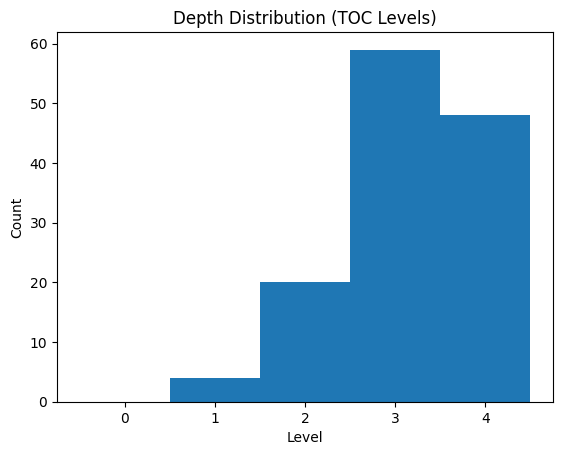

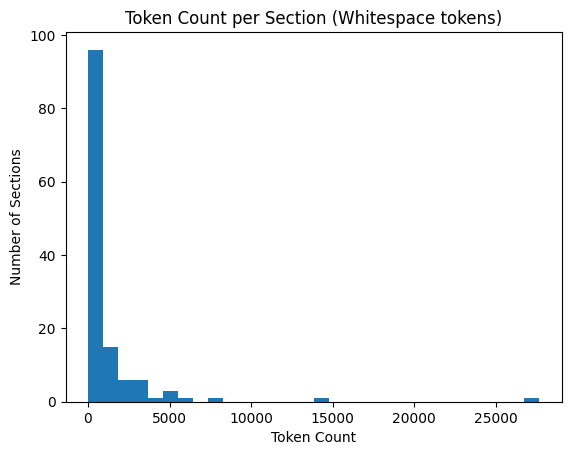

,level,normative,tags,tokens,tables,figures,sections,normative_density_per_1k_tokens,tag_density_per_1k_tokens
0,1,240,206,48762,54,14,4,4.921865,4.224601
1,2,239,206,48499,54,14,20,4.927937,4.247510
2,3,204,181,42457,50,11,59,4.804861,4.263137
3,4,71,116,21567,35,13,48,3.292067,5.378588


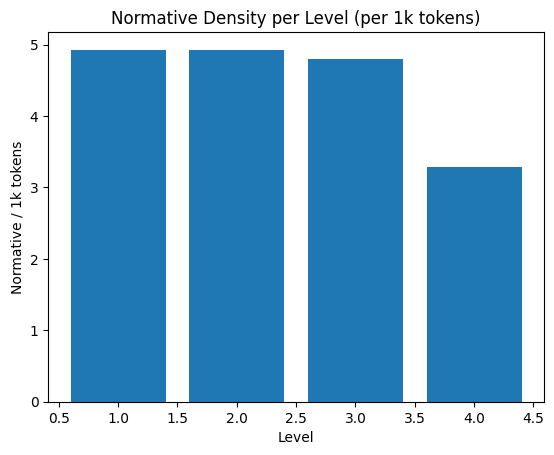

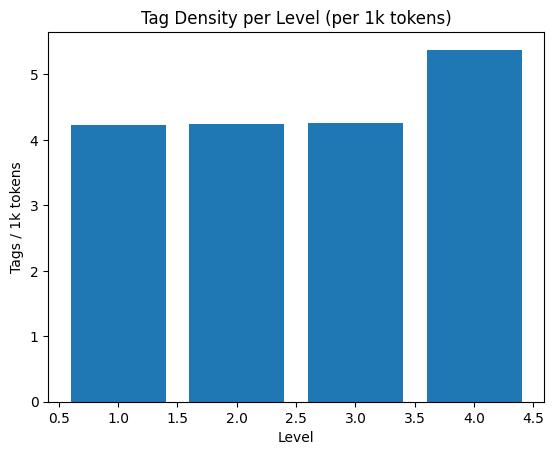

In [10]:
# STAGE 7 — Structural Visualization (matplotlib only)

# Depth distribution histogram (TOC-based)
if not df_toc2.empty:
    levels = df_toc2["level"].astype(int).values
    plt.figure()
    plt.hist(levels, bins=range(0, int(levels.max()) + 2), align="left")
    plt.title("Depth Distribution (TOC Levels)")
    plt.xlabel("Level")
    plt.ylabel("Count")
    plt.show()

# Token count per section histogram
if not df_metrics.empty:
    plt.figure()
    plt.hist(df_metrics["token_count"].astype(int).values, bins=30)
    plt.title("Token Count per Section (Whitespace tokens)")
    plt.xlabel("Token Count")
    plt.ylabel("Number of Sections")
    plt.show()

# Normative density per level (bar)
if not df_metrics.empty:
    by_level = (df_metrics.groupby("level", as_index=False)
                .agg(normative=("normative_count","sum"),
                     tags=("tag_count","sum"),
                     tokens=("token_count","sum"),
                     tables=("table_count","sum"),
                     figures=("figure_count","sum"),
                     sections=("section_id","count")))
    by_level["normative_density_per_1k_tokens"] = (by_level["normative"] / by_level["tokens"].replace(0, np.nan)) * 1000.0
    by_level["tag_density_per_1k_tokens"] = (by_level["tags"] / by_level["tokens"].replace(0, np.nan)) * 1000.0

    display(by_level)

    plt.figure()
    plt.bar(by_level["level"].astype(int).values, by_level["normative_density_per_1k_tokens"].fillna(0.0).values)
    plt.title("Normative Density per Level (per 1k tokens)")
    plt.xlabel("Level")
    plt.ylabel("Normative / 1k tokens")
    plt.show()

    plt.figure()
    plt.bar(by_level["level"].astype(int).values, by_level["tag_density_per_1k_tokens"].fillna(0.0).values)
    plt.title("Tag Density per Level (per 1k tokens)")
    plt.xlabel("Level")
    plt.ylabel("Tags / 1k tokens")
    plt.show()

In [11]:
# STAGE 8 — Structural Insights Extraction (print + save summary.json)
# Requirements:
# - max depth, avg depth, depth distribution
# - which levels contain longest sections
# - appendices differences (size/density)
# - top 10 sections for tags, normative, crossrefs
# - each section in summary includes line/word/char/token counts + tables/figures counts + other fields

def top_n(df: pd.DataFrame, col: str, n: int = 10) -> List[Dict[str, Any]]:
    if df.empty:
        return []
    cols = ["section_id","title","level","start_page","end_page",col,"token_count","word_count","line_count"]
    top = df.sort_values(col, ascending=False).head(n)[cols]
    return top.to_dict(orient="records")

def longest_by_level(df: pd.DataFrame, n: int = 5) -> Dict[str, Any]:
    out = {}
    if df.empty:
        return out
    for lvl, g in df.groupby("level"):
        top = g.sort_values("token_count", ascending=False).head(n)
        out[str(int(lvl))] = top[["section_id","title","token_count","word_count","line_count","start_page","end_page"]].to_dict(orient="records")
    return out

def appendix_comparison(df: pd.DataFrame) -> Dict[str, Any]:
    if df.empty:
        return {"appendix_present": False}
    is_app = df["section_id"].astype(str).str.match(r"^(Appendix|Annex)\s+[A-Z]\b", case=False, na=False)
    app = df[is_app].copy()
    main = df[~is_app].copy()
    if app.empty:
        return {"appendix_present": False}

    def agg(x: pd.DataFrame) -> Dict[str, Any]:
        tokens = int(x["token_count"].sum())
        return {
            "sections": int(len(x)),
            "tokens": tokens,
            "words": int(x["word_count"].sum()),
            "lines": int(x["line_count"].sum()),
            "chars": int(x["char_count"].sum()),
            "normative": int(x["normative_count"].sum()),
            "tags": int(x["tag_count"].sum()),
            "crossrefs": int(x["crossref_count"].sum()),
            "tables": int(x["table_count"].sum()),
            "figures": int(x["figure_count"].sum()),
            "normative_per_1k_tokens": float((x["normative_count"].sum() / max(1, tokens)) * 1000.0),
            "tags_per_1k_tokens": float((x["tag_count"].sum() / max(1, tokens)) * 1000.0),
        }

    return {
        "appendix_present": True,
        "appendix": agg(app),
        "non_appendix": agg(main)
    }

depth_distribution = depth_summary["depth_distribution"]
max_depth = depth_summary["max_depth"]
avg_depth = depth_summary["avg_depth"]

# 1. Define the list of columns you want to keep
keep_cols = [
    "node_id", "section_id", "title", "level", "parent_node_id", 
    "start_page", "end_page", "line_count", "char_count", 
    "word_count", "token_count", "table_count", "figure_count"
]

# 2. Filter, Sort, and Convert
sections_summary = (
    df_metrics[keep_cols]
    .sort_values(["start_page"], ascending=[True])
    .to_dict(orient="records")
)
summary = {
    "document": {
        "pdf_path": str(PDF_PATH),
        "extractor": "pdfplumber",
        "num_pages": int(df_pages["page_num"].nunique()),
        "toc_pages": [TOC_START_PAGE, TOC_END_PAGE],
    },
    "hierarchy": {
        "max_depth": int(max_depth),
        "avg_depth": float(avg_depth),
        "depth_distribution": {str(k): int(v) for k, v in depth_distribution.items()},
        "num_headings_from_toc": int(len(df_toc2)),
    },
    "sections": sections_summary
}

with open(OUT_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved summary.json")
print(json.dumps(summary["hierarchy"], indent=2))
display(pd.DataFrame(summary["sections"]).head(10))

Saved summary.json
{
  "max_depth": 4,
  "avg_depth": 3.1526717557251906,
  "depth_distribution": {
    "1": 4,
    "2": 20,
    "3": 59,
    "4": 48
  },
  "num_headings_from_toc": 131
}


,node_id,section_id,title,level,parent_node_id,start_page,end_page,line_count,char_count,word_count,token_count,table_count,figure_count
0,T1:Part I,Part I,General,1,None,11,35,658,28986,4469,4441,0,0
1,T2:1,1,Scope,2,T1:Part I,12,13,47,2613,365,371,0,0
2,T3:1.1,1.1,Changes in Version 4.4,3,T2:1,12,12,4,252,36,36,0,0
3,T4:1.2,1.2,Structure,3,T2:1,12,13,22,1075,146,156,0,0
4,T5:1.3,1.3,Underlying Standards,3,T2:1,13,13,4,268,42,41,0,0
5,T6:1.4,1.4,Audience,3,T2:1,13,13,3,208,28,28,0,0
6,T7:2,2,Normative References,2,T1:Part I,14,16,92,4530,606,597,0,0
7,T8:3,3,Definitions,2,T1:Part I,17,24,240,11830,1830,1826,0,0
8,T9:4,4,"Abbreviations, Notations, Conventions, and Ter...",2,T1:Part I,25,35,274,9912,1655,1634,0,0
9,T10:4.1,4.1,Abbreviations,3,T9:4,25,31,181,5162,787,760,0,0


In [12]:
# # MANUAL VALIDATION HELPER — show TOC heading(s) and matched location, plus page text with markers

# PAGE_TO_VALIDATE = 10  # change

# def headings_matched_on_page(df_pos3: pd.DataFrame, page_num: int) -> pd.DataFrame:
#     x = df_pos3[df_pos3["page"] == page_num].copy()
#     return x.sort_values("global_line_idx")

# def highlight_matches_in_page(df_lines: pd.DataFrame, df_pos3: pd.DataFrame, page_num: int) -> str:
#     page_lines = df_lines[df_lines["page_num"] == page_num].sort_values("line_idx_in_page")
#     matches = headings_matched_on_page(df_pos3, page_num)
#     match_line_idxs = set(matches["line_idx_in_page"].dropna().astype(int).tolist())

#     out = []
#     for _, r in page_lines.iterrows():
#         if int(r["line_idx_in_page"]) in match_line_idxs:
#             out.append(f">>> MATCHED HEADING <<< {r['line_text']}")
#         else:
#             out.append(f"                    {r['line_text']}")
#     return "\n".join(out)

# print(f"PAGE_TO_VALIDATE = {PAGE_TO_VALIDATE}")
# display(headings_matched_on_page(df_pos3, PAGE_TO_VALIDATE)[
#     ["section_id","title","level","match_type","match_confidence","matched_text","toc_page_ref"]
# ].head(50))

# print("\n--- PAGE TEXT (matched headings highlighted) ---\n")
# print(highlight_matches_in_page(df_lines, df_pos3, PAGE_TO_VALIDATE))

In [13]:
# # FINAL DELIVERABLE CHECK — verify required output files exist

# required_files = [
#     "hierarchy.json",
#     "headings.csv",
#     "sections.csv",
#     "metrics.csv",
#     "summary.json",
# ]

# missing_out = [f for f in required_files if not (OUT_DIR / f).exists()]
# if missing_out:
#     print("Missing required outputs:", missing_out)
# else:
#     print("All required deliverables are present:")
#     for f in required_files:
#         print(" -", f)